## Aim: To get familiar with OpenCV operations
### Note: Use matplotlib or OpenCV to display images and write the code after the #Answer comment
### Grade points = 20%
### Please submit the notebook as the submission and make sure output for each cell is displayed and all cells are executed

## Important Note: Please submit your original work and don't share your work with others

Dimensions of the image: (739, 600, 3)
Total number of pixels: 1330200


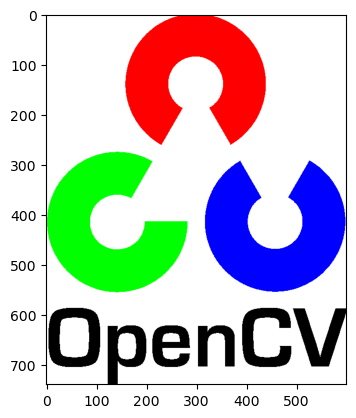

In [22]:
#### Question no 1

#read image opencv-logo
#display shape and size of the image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

#Answer
# Load the image from file
img = cv2.imread('opencv-logo.png')

# Display image properties
print("Dimensions of the image:", img.shape)
print("Total number of pixels:", img.size)

# Convert color format and display the image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

#### Question no 2

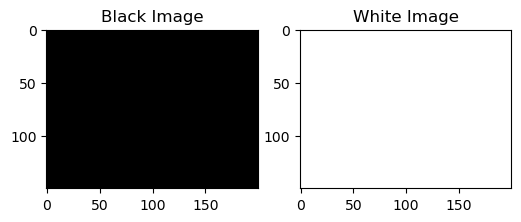

In [23]:
#create a numpy array of zeroes that is 150 pixels tall, 200 pixels wide
#display this black image
#Similarly create a numpy array on ones with above dimensions and display the white image

# Answer
# Generate a black image (all zeros)
black_img = np.full((150, 200), 0, dtype=np.uint8)

# Generate a white image (all ones multiplied by 255)
white_img = np.full((150, 200), 255, dtype=np.uint8)

# Plot both images side by side
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(black_img, cmap='gray', vmin=0, vmax=255)
plt.title('Black Image')

plt.subplot(1, 2, 2)
plt.imshow(white_img, cmap='gray', vmin=0, vmax=255)
plt.title('White Image')

plt.show()

#### Question no 3

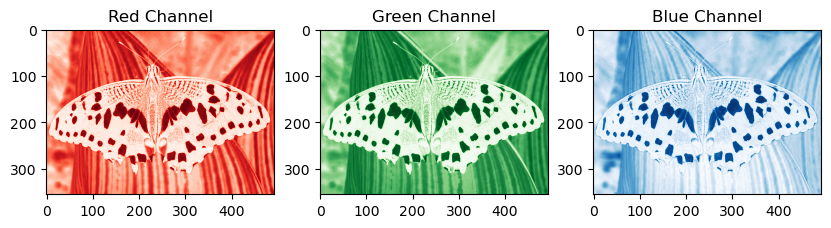

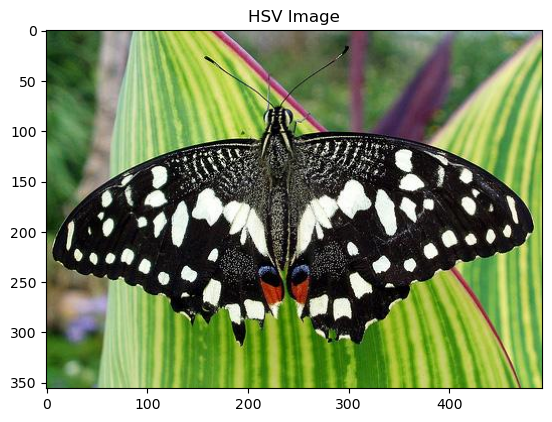

In [24]:
#read the butterfly image and display the r,g,b channels of the image
#Then display the butterfly image in the HSV color space

# Answer
img = cv2.imread('butterfly.jpg')
blue, green, red = cv2.split(img)
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(red, cmap='Reds')
plt.title('Red Channel')

plt.subplot(1, 3, 2)
plt.imshow(green, cmap='Greens')
plt.title('Green Channel')

plt.subplot(1, 3, 3)
plt.imshow(blue, cmap='Blues')
plt.title('Blue Channel')
plt.show()

plt.imshow(cv2.cvtColor(hsv_img, cv2.COLOR_HSV2RGB))
plt.title('HSV Image')
plt.show()


#### Question no 4

5x5 Array with 10s:
 [[10 10 10 10 10]
 [10 10 10 10 10]
 [10 10 10 10 10]
 [10 10 10 10 10]
 [10 10 10 10 10]]
Randomly Generated Array:
 [[138 227 154 104 183]
 [211 162 110 205 241]
 [ 61 152 229  96 211]
 [ 78  84  76 218   6]
 [186 218 156 196   6]]
Maximum Value: 241 Minimum Value: 6


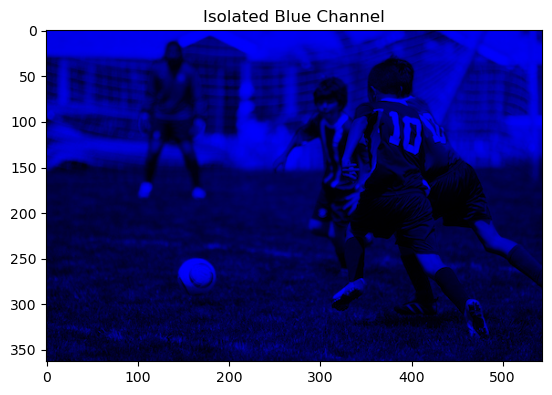

In [25]:
#create a 5 by 5 array where every number is a 10
#run the cell below to create an array of random numbers and see if you can figure out how it works.
#what are the largest and smalled values in this array?
#use PIL and matplotlib to read and display the any image of your choice from the given images.
#convert the image to a NumPy Array
#use slicing to set the RED and GREEN channels of the picture to 0, then use imshow() to show the isolated blue channel

# Answer
# Create a 5x5 array filled with 10s
array_of_tens = np.full((5, 5), 10, dtype=np.uint8)

# Generate a random 5x5 array with values between 0 and 255
random_values = np.random.randint(0, 256, (5, 5), dtype=np.uint8)

print("5x5 Array with 10s:\n", array_of_tens)
print("Randomly Generated Array:\n", random_values)
print("Maximum Value:", random_values.max(), "Minimum Value:", random_values.min())

# Open an image and convert it to a numpy array
image_pil = Image.open('players.jpg')
image_array = np.array(image_pil)

# Set the Red and Green channels to 0 to isolate the Blue channel
image_array[:, :, 0] = 0  # Remove Red
image_array[:, :, 1] = 0  # Remove Green

# Display the image with only the Blue channel
plt.imshow(image_array)
plt.title('Isolated Blue Channel')
plt.show()

#### Question no 5

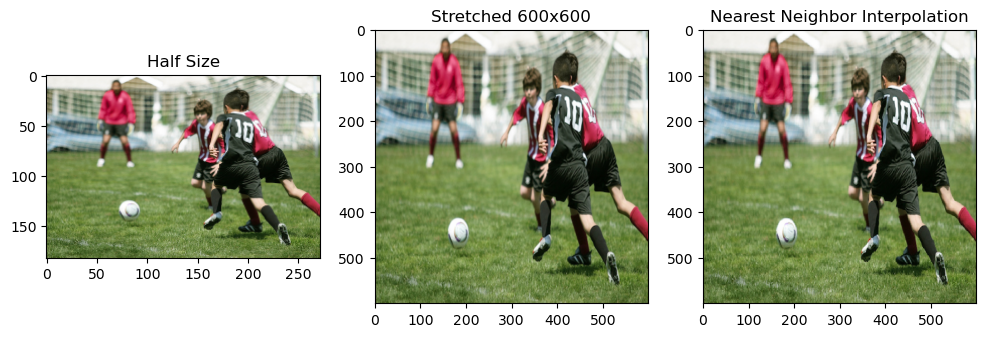

In [26]:
#read in the players image
#Perform scaling using resize method
#a) half the image using dim=(0,0), fx=0.5, fy=0.5
#b) stretch the image to dim = (600,600)
#c) stretch the image to dim = (600,600 using interpolation=cv2.INTER_NEAREST

# Answer
# Load the image
players_image = cv2.imread('players.jpg')

# Resize the image to half of its original size
half_resized = cv2.resize(players_image, (0, 0), fx=0.5, fy=0.5)

# Resize the image to 600x600 with default interpolation
resized_stretched = cv2.resize(players_image, (600, 600))

# Resize the image to 600x600 using nearest neighbor interpolation
resized_nearest = cv2.resize(players_image, (600, 600), interpolation=cv2.INTER_NEAREST)

# Plot the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(half_resized, cv2.COLOR_BGR2RGB))
plt.title('Half Size')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(resized_stretched, cv2.COLOR_BGR2RGB))
plt.title('Stretched 600x600')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(resized_nearest, cv2.COLOR_BGR2RGB))
plt.title('Nearest Neighbor Interpolation')
plt.show()

#### Question no 6

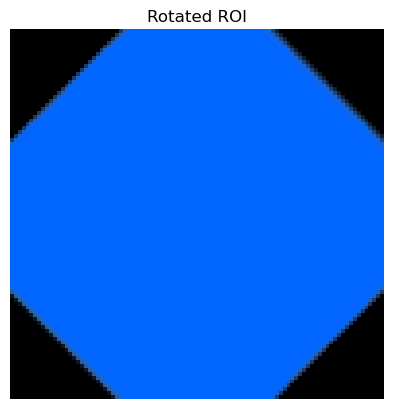

In [27]:
#read in the detect_blob image
#then draw a box shape around the blue solid box in the image that is your region of interest
#crop your region of interest
#and then rotate it 45 degrees so that it is not clipped

# Answer
blob_img = cv2.imread('detect_blob.png')
hsv_blob = cv2.cvtColor(blob_img, cv2.COLOR_BGR2HSV)
mask = cv2.inRange(hsv_blob, np.array([100, 150, 50]), np.array([140, 255, 255]))
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    roi = blob_img[y:y+h, x:x+w]
    matrix = cv2.getRotationMatrix2D((w//2, h//2), 45, 1.0)
    rotated = cv2.warpAffine(roi, matrix, (w, h))
    plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
    plt.title('Rotated ROI')
    plt.axis('off')
    plt.show()

#### Question no 7

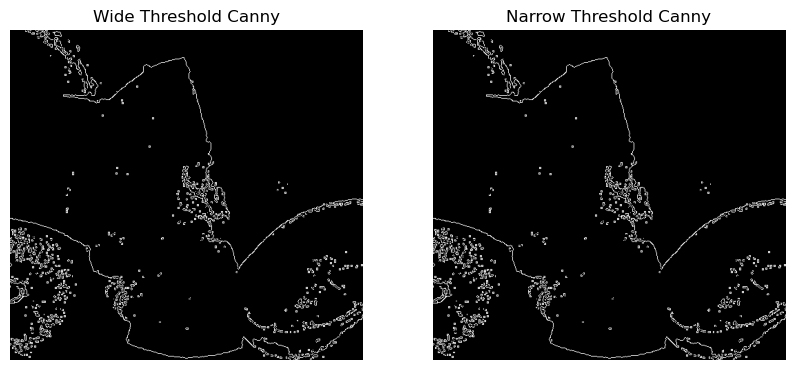

In [28]:
#read in the thresh image, perform thresholding by using gaussian blur with thresholds 5,55
#then perform dilation, erosion, opening & closing using a 5x5 kernel with 1 iteration on the original thresh image (Hint: look into Opencv for operations)
#Finally apply canny edge detection - experiment using wide and narrow thresholds 
#(so just 2 images in total one wide and one narrow)

#Answer
thresh_img = cv2.imread('thresh.jpg', cv2.IMREAD_GRAYSCALE)
blurred_img = cv2.GaussianBlur(thresh_img, (5, 5), 0)
_, binarized = cv2.threshold(blurred_img, 5, 55, cv2.THRESH_BINARY)

kernel = np.ones((5, 5), np.uint8)
dilated_img = cv2.dilate(binarized, kernel, iterations=1)
eroded_img = cv2.erode(binarized, kernel, iterations=1)
opened = cv2.morphologyEx(binarized, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(binarized, cv2.MORPH_CLOSE, kernel)

wide_edges = cv2.Canny(thresh_img, 50, 150)
narrow_edges = cv2.Canny(thresh_img, 100, 200)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(wide_edges, cmap='gray')
plt.title('Wide Threshold Canny')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(narrow_edges, cmap='gray')
plt.title('Narrow Threshold Canny')
plt.axis('off')
plt.show()

#### Question no 8

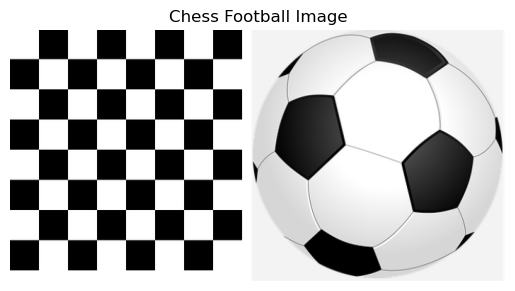

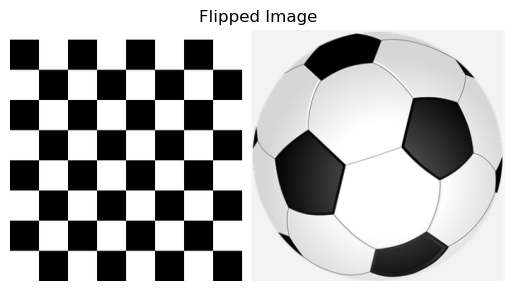

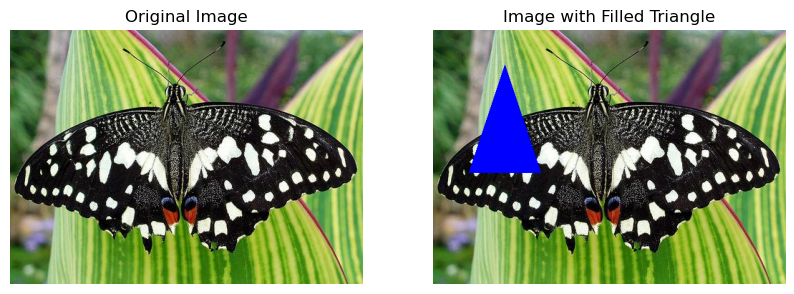

In [29]:
#read in the butterfly image
#open the chess_football image and display it in the notebook. Make sure to correct for the RGB order
#flip the image upside down and display it in the notebook.
#draw an empty RED rectangle around the butterfly and display the image in the notebook.
#draw a BLUE TRIANGLE in the middle of the image. The size and angle is up to you, but it should be a triangle (three sides) in any orientation.
#now fill in this triangle
#display the original image as well as the resultant image

#Answer
# Load images
butterfly_img = cv2.imread('butterfly.jpg')
chess_football_img = cv2.imread('chess_football.png')
chess_football_img = cv2.cvtColor(chess_football_img, cv2.COLOR_BGR2RGB)

# Display chess football image
plt.imshow(chess_football_img)
plt.title('Chess Football Image')
plt.axis('off')
plt.show()

# Flip the image vertically
flipped_img = cv2.flip(chess_football_img, 0)
plt.imshow(flipped_img)
plt.title('Flipped Image')
plt.axis('off')
plt.show()

# Draw a rectangle on the butterfly image
butterfly_with_rect = butterfly_img.copy()
cv2.rectangle(butterfly_with_rect, (50, 50), (200, 200), (0, 0, 255), 2)

# Define and draw a triangle
triangle_points = np.array([[100, 50], [50, 200], [150, 200]], np.int32)
cv2.polylines(butterfly_with_rect, [triangle_points], isClosed=True, color=(255, 0, 0), thickness=2)

# Fill the triangle on a new copy of the butterfly image
butterfly_filled_triangle = butterfly_img.copy()
cv2.fillPoly(butterfly_filled_triangle, [triangle_points], color=(255, 0, 0))

# Display original and image with filled triangle side by side
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(butterfly_img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(butterfly_filled_triangle, cv2.COLOR_BGR2RGB))
plt.title('Image with Filled Triangle')
plt.axis('off')
plt.show()

#### Question no 9

In [30]:
#create a script that opens the picture and allows you to draw empty red circles where ever you click the RIGHT MOUSE BUTTON DOWN

#Answer
def circle_on_click(event, x, y, flags, param):
    if event == cv2.EVENT_RBUTTONDOWN:
        cv2.circle(img, (x, y), 20, (0, 0, 255), 2)
        cv2.imshow('Updated Image', img)

# Load the image
img = cv2.imread('players.jpg')

# Display the image
cv2.imshow('Updated Image', img)

# Set mouse callback to draw circle on right-click
cv2.setMouseCallback('Updated Image', circle_on_click)

# Wait for a key press and close the window
cv2.waitKey(0)
cv2.destroyAllWindows()

#### Question no 10

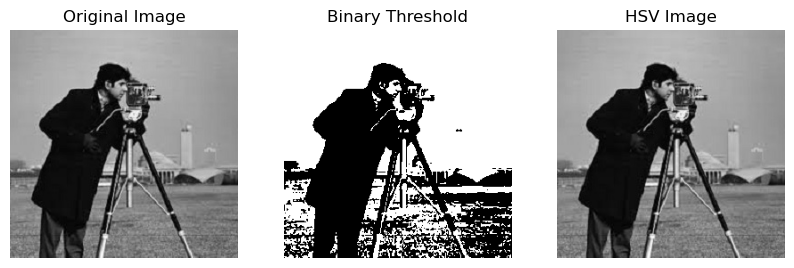

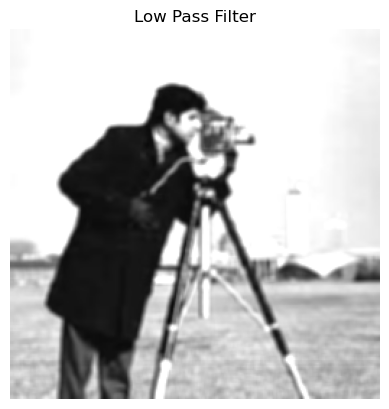

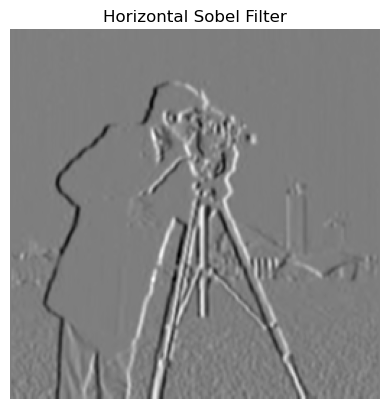

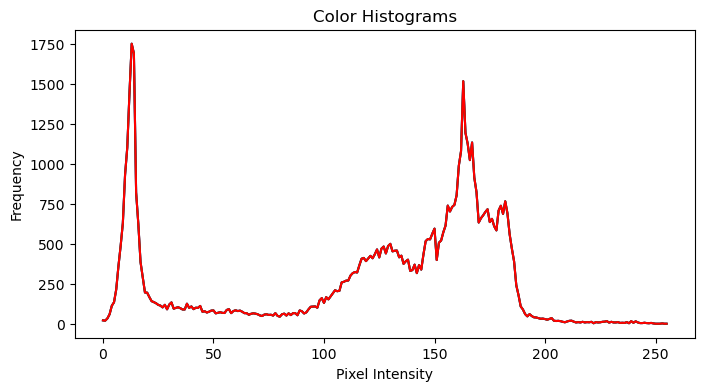

In [31]:
#open and display the any image of your choice
#apply a binary threshold onto the image
#convert image colorspace to HSV and display the image
#create a low pass filter with a 4 by 4 Kernel filled with values of 1/10 (0.01) and then use 2-D Convolution to blur the image (displayed in normal RGB)
#create a Horizontal Sobel Filter with a kernel size of 5 to the grayscale version of the image and then display the resulting gradient filtered version of the image.
#plot the color histograms for the RED, BLUE, and GREEN channel of the image. Pay careful attention to the ordering of the channels

#Answer
# Load the image
img = cv2.imread('cameraman.jpg')

# Display the original image
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Convert the image to grayscale and apply binary threshold
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary_img = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)
plt.subplot(1, 3, 2)
plt.imshow(binary_img, cmap='gray')
plt.title('Binary Threshold')
plt.axis('off')

# Convert to HSV color space
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(hsv_img, cv2.COLOR_HSV2RGB))
plt.title('HSV Image')
plt.axis('off')
plt.show()

# Apply 2D convolution with a low-pass filter
low_pass_kernel = np.ones((4, 4), np.float32) / 10
blurred_img = cv2.filter2D(img, -1, low_pass_kernel)
plt.imshow(cv2.cvtColor(blurred_img, cv2.COLOR_BGR2RGB))
plt.title('Low Pass Filter')
plt.axis('off')
plt.show()

# Apply the horizontal Sobel filter
sobel_x = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=5)
plt.imshow(sobel_x, cmap='gray')
plt.title('Horizontal Sobel Filter')
plt.axis('off')
plt.show()

# Plot the color histograms
color_channels = ('b', 'g', 'r')
plt.figure(figsize=(8, 4))
for idx, channel in enumerate(color_channels):
    histogram = cv2.calcHist([img], [idx], None, [256], [0, 256])
    plt.plot(histogram, color=channel)
plt.title('Color Histograms')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()


#### Thank You